<h1 style="color:blue;"> RER B Delay Prediction & Early-Warning System</h1>



<h2 style="color:green;">Project Overview</h2>

This project analyzes real-time public transport data from Île-de-France Mobilités to study and predict delays on the RER B railway line.

The project uses repeated SIRI Lite real-time snapshots collected over time to transform live transit data into a historical dataset of train journeys and stop-level observations.

<h3 style="color:pink;">Objectives</h3>

1. Analyze delay patterns across the RER B network.
2. Identify factors associated with delays.
3. Build a machine-learning model to predict future delays.
4. Develop an early-warning model capable of identifying emerging delays before they reach the 2-minute threshold.
5. Evaluate the models using metrics appropriate for an imbalanced classification problem.

<h3 style="color:pink;">Key Questions</h3>

- How frequently do delays occur?
- Do delays differ by direction and time of day?
- How strongly does a previous delay predict a subsequent delay?
- Can machine learning identify emerging delays early?
- What trade-off exists between detecting delays and avoiding false alerts?

<h3 style="color:pink;">Data Source</h3>

Real-time SIRI Lite data provided by Île-de-France Mobilités.

<h3 style="color:pink;">Prediction Target</h3>

A train is considered **delayed** when its predicted arrival is at least **2 minutes later** than its scheduled arrival.

<h1 style="color:red;">Imports</h1>

In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

<h1 style="color:red;">Locate our historical snapshots</h1>

In [4]:
# Use the folder containing the discovered snapshot files
RAW_DATA_DIR = os.path.dirname(matches[0])

snapshot_files = sorted(
    matches
)

print("Raw data folder:")
print(RAW_DATA_DIR)

print("\nSnapshots found:", len(snapshot_files))

Raw data folder:
..\transit-delay-prediction\data\raw

Snapshots found: 14


<h1 style="color:red;">Load the historical data</h1>

In [5]:
frames = []

for file in snapshot_files:
    df = pd.read_csv(file)
    frames.append(df)

historical_df = pd.concat(
    frames,
    ignore_index=True
)

print("Historical dataset:", historical_df.shape)

Historical dataset: (15252, 13)


<h1 style="color:red;">Clean and convert timestamps</h1>

In [6]:
datetime_columns = [
    "scheduled_arrival",
    "expected_arrival",
    "scheduled_departure",
    "expected_departure",
    "collection_time"
]

for column in datetime_columns:
    historical_df[column] = pd.to_datetime(
        historical_df[column],
        errors="coerce",
        utc=True
    )

historical_df["arrival_delay_min"] = (
    (
        historical_df["expected_arrival"]
        - historical_df["scheduled_arrival"]
    ).dt.total_seconds() / 60
)

historical_df["departure_delay_min"] = (
    (
        historical_df["expected_departure"]
        - historical_df["scheduled_departure"]
    ).dt.total_seconds() / 60
)

print(historical_df.shape)

(15252, 15)


<h1 style="color:red;"> Create the journey-stop history</h1><h2> create a unique identifier for each journey/stop </h2>

In [7]:
historical_df["journey_stop_id"] = (
    historical_df["journey_id"].astype(str)
    + "_"
    + historical_df["stop_id"].astype(str)
)

historical_df = historical_df.sort_values(
    ["journey_stop_id", "collection_time"]
).copy()

print(
    "Unique journey-stop combinations:",
    historical_df["journey_stop_id"].nunique()
)

print(
    "Repeated journey-stop observations:",
    (
        historical_df["journey_stop_id"]
        .value_counts() > 1
    ).sum()
)

Unique journey-stop combinations: 2106
Repeated journey-stop observations: 1694


<h2> create the historical delay features </h2>

In [8]:
historical_df["previous_delay_min"] = (
    historical_df
    .groupby("journey_stop_id")["arrival_delay_min"]
    .shift(1)
)

historical_df["previous_departure_delay_min"] = (
    historical_df
    .groupby("journey_stop_id")["departure_delay_min"]
    .shift(1)
)

historical_df["delay_change_min"] = (
    historical_df["arrival_delay_min"]
    - historical_df["previous_delay_min"]
)

<h1 style="color:red;">Create the prediction target</h1><h2>A future observation is considered delayed when its arrival delay is ≥ 2 minutes</h2>

In [9]:
historical_df["future_arrival_delay_min"] = (
    historical_df
    .groupby("journey_stop_id")["arrival_delay_min"]
    .shift(-1)
)

historical_df["target_delayed"] = (
    historical_df["future_arrival_delay_min"] >= 2
).astype("Int64")

<h2>create our time features</h2>

In [10]:
historical_df["scheduled_arrival_paris"] = (
    historical_df["scheduled_arrival"]
    .dt.tz_convert("Europe/Paris")
)

historical_df["hour"] = (
    historical_df["scheduled_arrival_paris"].dt.hour
)

historical_df["day_of_week"] = (
    historical_df["scheduled_arrival_paris"].dt.dayofweek
)

historical_df["minutes_to_scheduled"] = (
    (
        historical_df["scheduled_arrival"]
        - historical_df["collection_time"]
    ).dt.total_seconds() / 60
)

historical_df["minutes_to_scheduled"] = (
    historical_df["minutes_to_scheduled"]
    .clip(lower=0)
)

<h2 style="color:red;">Create the final modeling dataset</h1><h2>Remove observations where we don't have the historical information needed for prediction</h2>

In [11]:
model_df = historical_df.dropna(
    subset=[
        "previous_delay_min",
        "previous_departure_delay_min",
        "delay_change_min",
        "future_arrival_delay_min"
    ]
).copy()

print("Modeling dataset:", model_df.shape)

print("\nTarget distribution:")
print(model_df["target_delayed"].value_counts())

print("\nDelay percentage:")
print(
    round(
        model_df["target_delayed"].mean() * 100,
        2
    ),
    "%"
)

Modeling dataset: (10662, 25)

Target distribution:
target_delayed
0    9487
1    1175
Name: count, dtype: Int64

Delay percentage:
11.02 %


<h1 style="color:red;">Final exploratory analysis</h1><h2>Overall delay rate</h2>


In [12]:
delay_summary = pd.DataFrame({
    "status": ["On time", "Delayed"],
    "count": [
        (model_df["target_delayed"] == 0).sum(),
        (model_df["target_delayed"] == 1).sum()
    ]
})

delay_summary["percentage"] = (
    delay_summary["count"]
    / len(model_df)
    * 100
)

display(delay_summary)

,status,count,percentage
0,On time,9487,88.979554
1,Delayed,1175,11.020446


<h2>Delay rate by direction</h2>

In [13]:
direction_analysis = (
    model_df
    .groupby("direction")["target_delayed"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

direction_analysis["delay_rate_%"] = (
    direction_analysis["mean"] * 100
)

display(direction_analysis)

,direction,count,sum,mean,delay_rate_%
0,Aller,5375,1065,0.19814,19.813953
1,Retour,5287,110,0.020806,2.080575


<h2>Delay rate by hour</h2>

In [14]:
hour_analysis = (
    model_df
    .groupby("hour")["target_delayed"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

hour_analysis["delay_rate_%"] = (
    hour_analysis["mean"] * 100
)

display(hour_analysis)

,hour,count,sum,mean,delay_rate_%
0,18.0,3575,819,0.229091,22.909091
1,19.0,5791,353,0.060957,6.095666
2,20.0,1292,3,0.002322,0.232198
3,21.0,4,0,0.0,0.0


<h2>Create the two essential visualizations</h2>

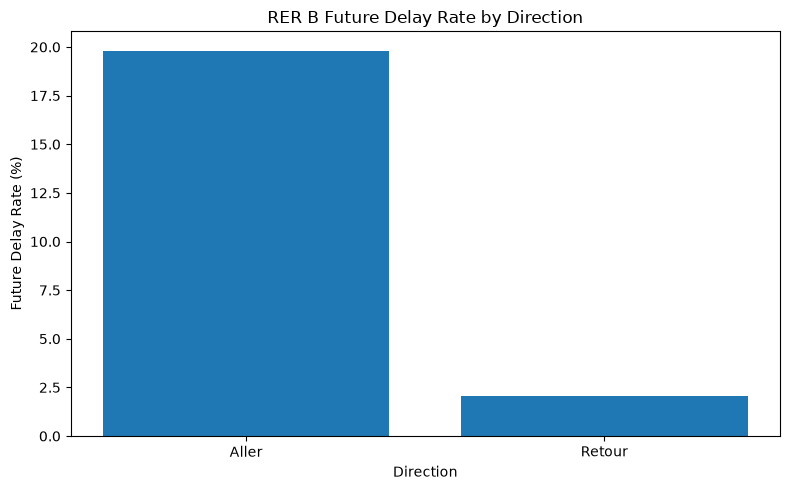

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    direction_analysis["direction"],
    direction_analysis["delay_rate_%"]
)

plt.xlabel("Direction")
plt.ylabel("Future Delay Rate (%)")
plt.title("RER B Future Delay Rate by Direction")

plt.tight_layout()
plt.show()

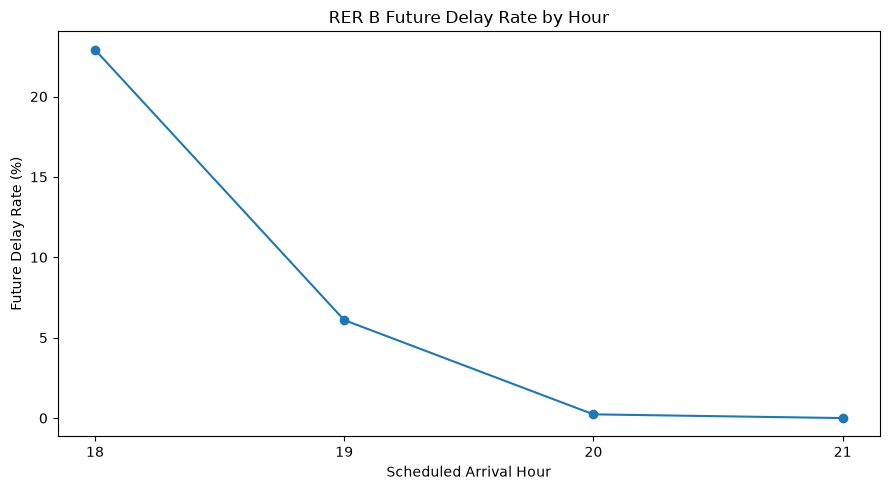

In [16]:
plt.figure(figsize=(9, 5))

plt.plot(
    hour_analysis["hour"],
    hour_analysis["delay_rate_%"],
    marker="o"
)

plt.xlabel("Scheduled Arrival Hour")
plt.ylabel("Future Delay Rate (%)")
plt.title("RER B Future Delay Rate by Hour")

plt.xticks(hour_analysis["hour"])

plt.tight_layout()
plt.show()

<h1 style="color:red;">Final chronological split</h1><h2>build the model</h2>



In [17]:
model_df = model_df.sort_values(
    "collection_time"
).copy()

split_index = int(len(model_df) * 0.8)

train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

print("\nTraining period:")
print(train_df["collection_time"].min())
print("→", train_df["collection_time"].max())

print("\nTesting period:")
print(test_df["collection_time"].min())
print("→", test_df["collection_time"].max())

Training rows: 8529
Testing rows: 2133

Training period:
2026-08-20 16:08:12.130584+00:00
→ 2026-08-20 16:48:29.542077+00:00

Testing period:
2026-08-20 16:48:29.542077+00:00
→ 2026-08-20 16:58:34.418372+00:00


<h1 style="color:red;">Final Random Forest</h1><h2>Model with stop information and the core temporal features</h2>

In [18]:
numeric_features = [
    "previous_delay_min",
    "minutes_to_scheduled",
    "hour",
    "day_of_week"
]

categorical_features = [
    "direction",
    "stop_id"
]

target = "target_delayed"

X_train = train_df[
    numeric_features + categorical_features
]

y_train = train_df[target]

X_test = test_df[
    numeric_features + categorical_features
]

y_test = test_df[target]

<h2>Preprocessing</h2>

In [19]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

<h2>Train</h2>

In [20]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)

print("Final Random Forest trained successfully.")

Final Random Forest trained successfully.


<h1 style="color:red;;">Final evaluation</h1>

In [21]:
final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred)
final_recall = recall_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)

print("FINAL RANDOM FOREST")
print("===================")

print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-score : {final_f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        final_pred,
        target_names=["On time", "Delayed"]
    )
)

FINAL RANDOM FOREST
Accuracy : 0.9180
Precision: 0.6463
Recall   : 0.7823
F1-score : 0.7078

Confusion Matrix:
[[1746  116]
 [  59  212]]

Classification Report:
              precision    recall  f1-score   support

     On time       0.97      0.94      0.95      1862
     Delayed       0.65      0.78      0.71       271

    accuracy                           0.92      2133
   macro avg       0.81      0.86      0.83      2133
weighted avg       0.93      0.92      0.92      2133



<h1 style="color:red;">Final confusion matrix</h1>

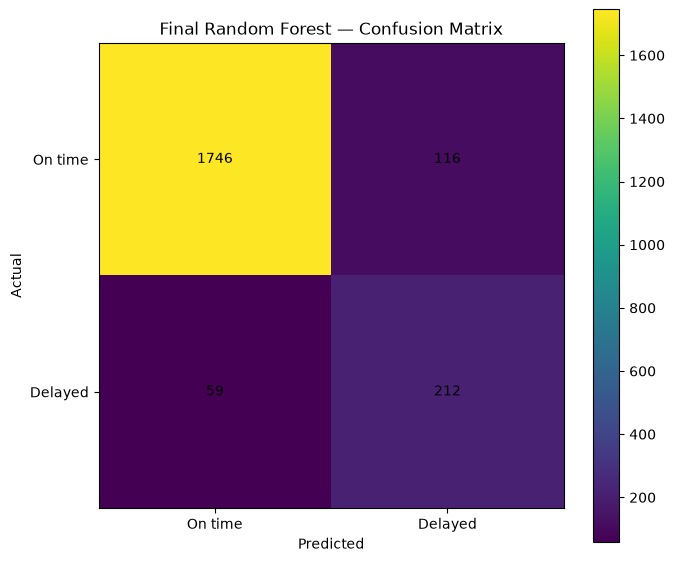

In [22]:
cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("Final Random Forest — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["On time", "Delayed"]
)

plt.yticks(
    [0, 1],
    ["On time", "Delayed"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()
plt.show()

<h1 style="color:red;">Feature importance</h1><h2>find why the model is making its predictions</h2>

In [23]:
feature_names = (
    final_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    final_model
    .named_steps["classifier"]
    .feature_importances_
)

feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values(
        "importance",
        ascending=False
    )
)

display(
    feature_importance.head(15)
)

,feature,importance
0,numeric__previous_delay_min,0.412735
1,numeric__minutes_to_scheduled,0.227485
5,categorical__direction_Retour,0.114593
4,categorical__direction_Aller,0.098491
2,numeric__hour,0.095823
35,categorical__stop_id_STIF:StopArea:SP:462398:,0.004702
8,categorical__stop_id_STIF:StopArea:SP:43071:,0.004375
32,categorical__stop_id_STIF:StopArea:SP:46163:,0.002939
12,categorical__stop_id_STIF:StopArea:SP:43122:,0.002936
19,categorical__stop_id_STIF:StopArea:SP:43193:,0.002809


<h2>create the chart</h2>

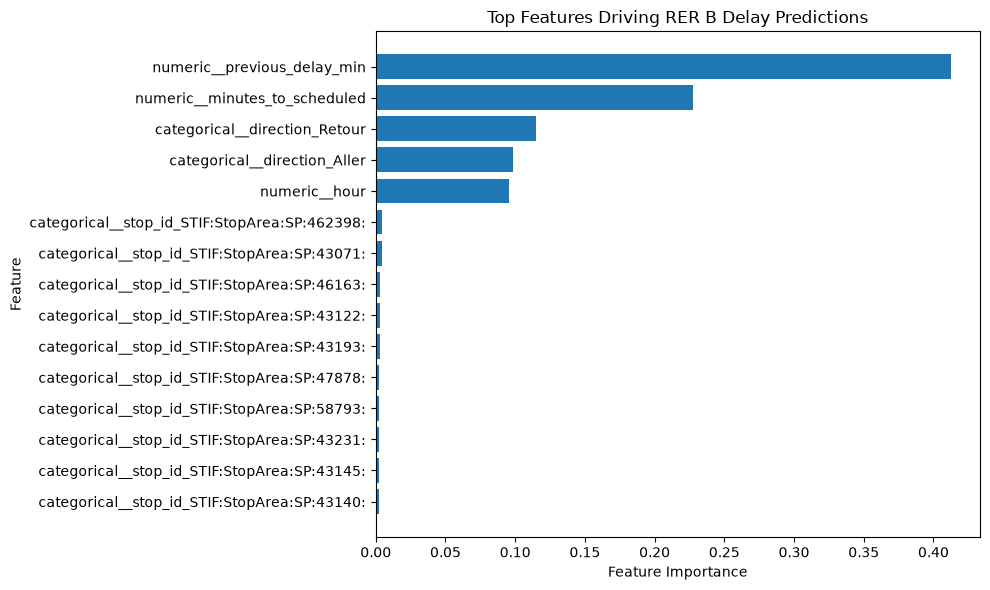

In [24]:
top_features = (
    feature_importance
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Features Driving RER B Delay Predictions")

plt.tight_layout()
plt.show()

<h1 style="color:red;">Save the final model</h1><h2>deployable model artifact</h2>

In [25]:
import joblib

MODEL_DIR = "../models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

model_path = os.path.join(
    MODEL_DIR,
    "rer_b_delay_random_forest.joblib"
)

joblib.dump(
    final_model,
    model_path
)

print("Model saved to:")
print(model_path)

Model saved to:
../models\rer_b_delay_random_forest.joblib


<h1 style="color:red;">Save the modeling dataset</h1>

In [26]:
DATA_PROCESSED_DIR = "../data/processed"

os.makedirs(
    DATA_PROCESSED_DIR,
    exist_ok=True
)

model_data_path = os.path.join(
    DATA_PROCESSED_DIR,
    "rer_b_delay_modeling_dataset.csv"
)

model_df.to_csv(
    model_data_path,
    index=False
)

print("Modeling dataset saved to:")
print(model_data_path)

Modeling dataset saved to:
../data/processed\rer_b_delay_modeling_dataset.csv


<h1 style="color:blue;">Conclusion</h1>



<h2 style="color:green;">Key Findings</h2>

This project developed a machine-learning pipeline for predicting RER B train delays using real-time SIRI Lite observations collected from Île-de-France Mobilités.

The final historical dataset contained **15,252 stop-level observations**, which were transformed into a modeling dataset of **10,662 observations** using repeated journey-stop snapshots.

<h3 style="color:pink;">Exploratory Findings</h3>

The analysis showed that delay risk varies across operational conditions, including:

- Direction of travel
- Time of day
- Previous observed delay
- Position along the route

The strongest predictor identified by the final Random Forest model was **previous delay**, accounting for approximately **41.3% of total feature importance**. The time remaining until the scheduled arrival was the second most important feature at approximately **22.7%**.

<h3 style="color:pink;">Final Model Performance</h3>

The final Random Forest classifier was evaluated using a chronological train/test split to avoid using future observations during training.

| Metric | Result |
|---|---:|
| Accuracy | **91.80%** |
| Precision | **64.63%** |
| Recall | **78.23%** |
| F1-score | **70.78%** |

The model correctly identified **212 of 271 delayed observations**, while producing 116 false positive alerts.

<h3 style="color:pink;">Interpretation</h3>

The results demonstrate that real-time transit data can be transformed into a useful predictive system for delay monitoring.

The strong importance of previous delay also highlights an important characteristic of railway operations: **delays tend to persist over successive observations of the same journey and stop**.

At the same time, the contribution of time, direction, and stop-level information suggests that delay prediction is influenced by the broader operational context rather than by a single factor.

<h3 style="color:pink;">Limitations</h3>

This project was developed using a relatively short collection period. The model therefore captures patterns present during the observed period and may not generalize equally well across different days, seasons, disruptions, or unusual operating conditions.

Future versions could incorporate:

- Longer historical collection periods
- Weather conditions
- Service disruptions and incidents
- Passenger demand
- Network-wide delay propagation
- More advanced time-series or gradient-boosting models

<h3 style="color:pink;">Final Takeaway</h3>

The project demonstrates an end-to-end data science workflow:

**Real-time data collection → Data engineering → Exploratory analysis → Feature engineering → Machine learning → Evaluation → Model interpretation**

The resulting system provides a foundation for an operational RER B delay-monitoring and early-warning application.

<h1 style="color:red;">Save the figures</h1><h2>Create the figures directory</h2>


In [27]:
import os

FIGURES_DIR = "../figures"

os.makedirs(FIGURES_DIR, exist_ok=True)

print("Figures directory ready:", FIGURES_DIR)

Figures directory ready: ../figures


<h2>save the "delay rate by direction"</h2>

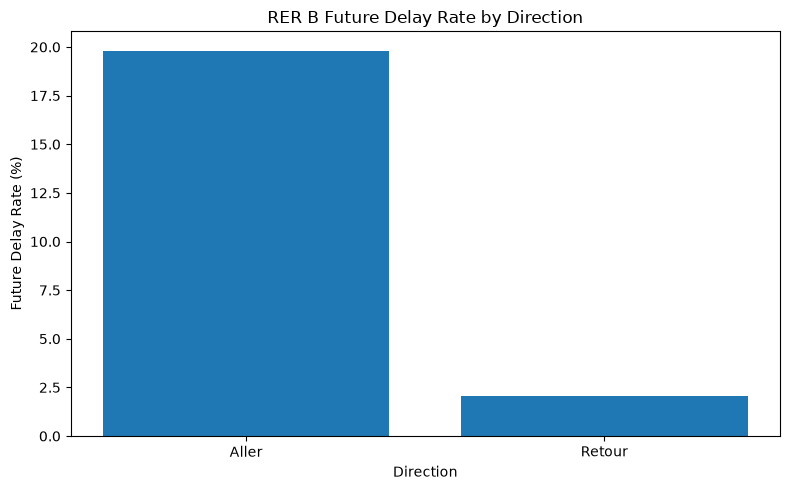

In [28]:
plt.figure(figsize=(8, 5))

plt.bar(
    direction_analysis["direction"],
    direction_analysis["delay_rate_%"]
)

plt.xlabel("Direction")
plt.ylabel("Future Delay Rate (%)")
plt.title("RER B Future Delay Rate by Direction")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "delay_rate_by_direction.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<h2>save the "delay rate by hour"</h2>

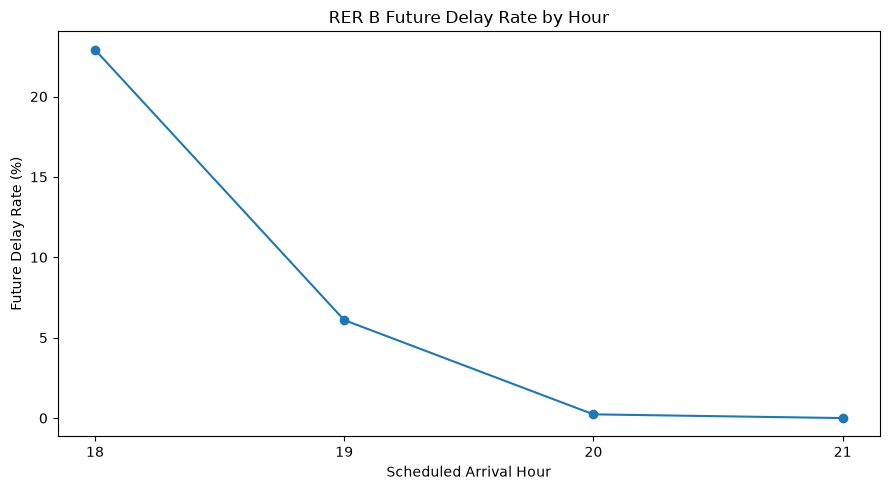

In [29]:
plt.figure(figsize=(9, 5))

plt.plot(
    hour_analysis["hour"],
    hour_analysis["delay_rate_%"],
    marker="o"
)

plt.xlabel("Scheduled Arrival Hour")
plt.ylabel("Future Delay Rate (%)")
plt.title("RER B Future Delay Rate by Hour")

plt.xticks(hour_analysis["hour"])

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "delay_rate_by_hour.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<h2>Save the confusion matrix</h2>

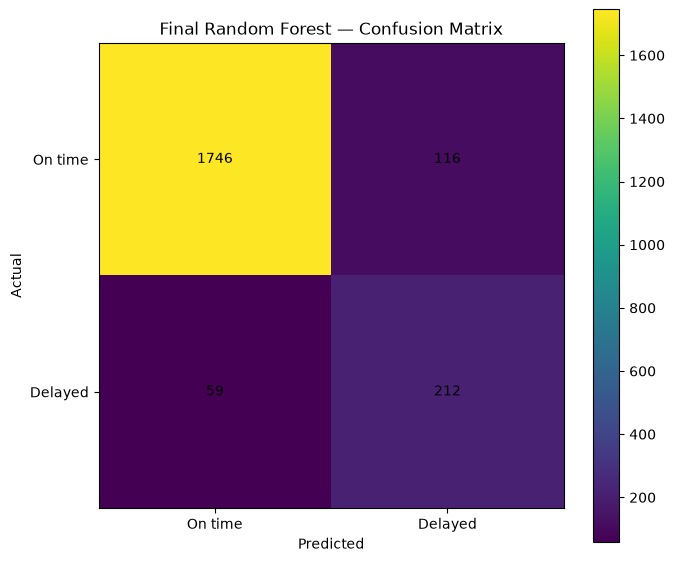

In [30]:
plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("Final Random Forest — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["On time", "Delayed"])
plt.yticks([0, 1], ["On time", "Delayed"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<h2>Save the feature importance</h2>

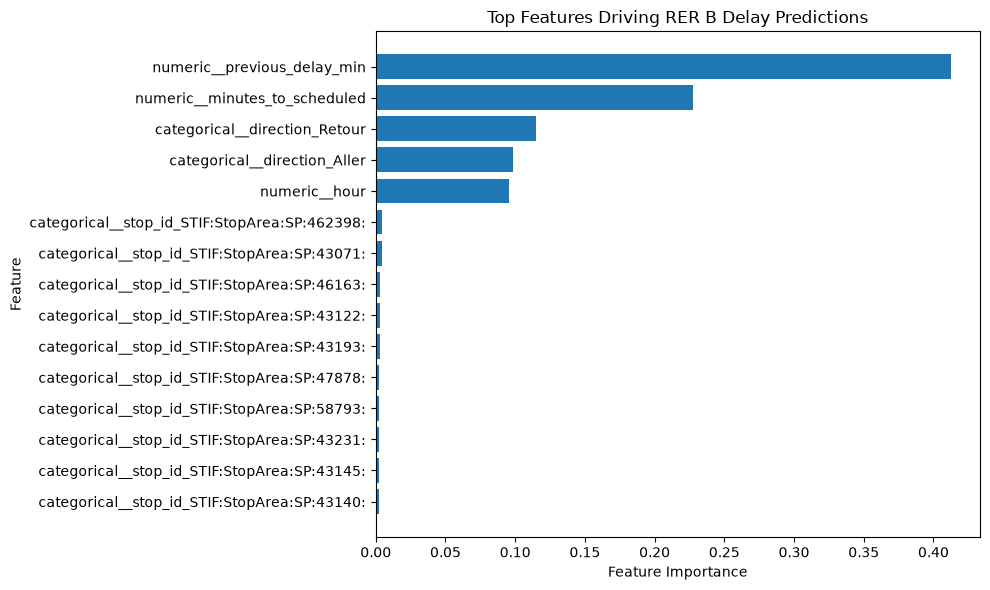

In [31]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Features Driving RER B Delay Predictions")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "feature_importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()